In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from scipy.ndimage import median_filter
import sys
import os
import struct
from pathlib import Path
import pickle

# Add project 'src' directory to sys.path when running from the notebooks/ folder
# (notebooks/ is expected to be inside the repo; repo_root = parent of cwd)
repo_root = Path.cwd().parent
src_path = str(repo_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Import modules from the installed package. If this fails, the editable install
# (`pip install -e .`) may be missing or kernel needs restart.
try:
    from ec.func_read_data import *
    from mo.func_mo import *
    from spc.normalize import *
    from plotting.funcs_plots import *
    from ec.sensor_info import *
    from ec.func_dr import *
    from ec.func_mrfd import *
except Exception as e:
    print('Package import failed:', e)
    print('Make sure you ran `pip install -e .` (editable install) and restart the kernel, or that src/ exists at:', src_path)
else:
    # For development: auto-reload modules (keep this enabled while editing source files)
    %load_ext autoreload
    %autoreload 2


import wrf
import glob
import xarray as xr
import netCDF4
from datetime import datetime, timedelta
from scipy.interpolate import griddata


In [2]:
import wrf
import glob
import xarray as xr
import netCDF4
from datetime import datetime, timedelta
from scipy.interpolate import griddata


In [3]:
"""READ IN LOWDATA FILES"""
folder_observations = Path('/capstor/scratch/cscs/rengbers/slow_data/')
data_obs=read_data(folder_observations, 'slow', sensor='SFC')
data_obs=clean_slowdata(data_obs)


"""READ IN EDDYPRO FILES"""
folder_ec = Path('/capstor/scratch/cscs/rengbers/ec_data/')
sensor='SFC_DR'
fluxes_SFC = read_eddypro_data(folder_ec, sensor)
fluxes_SFC_qc = read_eddypro_data(folder_ec, sensor, qc=True)
sensor='CSAT_16m_DR'
fluxes_16m = read_eddypro_data(folder_ec, sensor)
fluxes_16m_qc = read_eddypro_data(folder_ec, sensor, qc=True)
sensor='CSAT_26m_DR'
fluxes_26m = read_eddypro_data(folder_ec, sensor)
fluxes_26m_qc = read_eddypro_data(folder_ec, sensor, qc=True)


"READ MO FLUX DATA"
folder="../"
MO_data=pd.read_csv(folder+'MO_fluxes_2024.csv', parse_dates=['time'], index_col=['time'])

Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240118_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240120_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240122_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240201_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240205_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240214_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240220_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20241223_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250208_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250211_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC/02
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC/02/11
Found wind file: CR6_STN1wind.csv
Reading data from /ca

/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file, header=1) for file in files],
/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file, header=1) for file in files],
/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: Dt

Files found: ['/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202407/eddypro_Jul2024_qc_details_2025-05-22T164622_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202412/eddypro_Dec2024_qc_details_2025-05-23T123929_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202402/eddypro_Feb2024_qc_details_2025-05-22T112810_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202405/eddypro_May2024_qc_details_2025-05-22T145422_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202411/eddypro_Nov2024_qc_details_2025-05-23T115956_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202410/eddypro_Oct2024_qc_details_2025-05-23T110946_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202403/eddypro_Mar2024_qc_details_2025-05-22T130802_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202409/eddypro_Sep2024_qc_details_2025-05-23T102118_adv.

In [3]:
coords_PEA = [-71.94958, 23.35013]  # lat, lon

In [ ]:
"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
start_file = 'outhist_d04_2024-05-12_13:00:00.nc'
end_file = 'outhist_d04_2024-05-13_13:00:00.nc'
selected_files = [
    ncdf for ncdf in sorted(glob.glob(pattern))
    if start_file <= Path(ncdf).name <= end_file
]
for ncdf in selected_files:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist

# Get atmospheric surface variables
ter = wrf.getvar(wrflist, 'ter', timeidx=0, method="cat")
u10 = wrf.getvar(wrflist, "U10", timeidx=wrf.ALL_TIMES, method="cat")
v10 = wrf.getvar(wrflist, "V10", timeidx=wrf.ALL_TIMES, method="cat")
w10 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
w10=w10.isel(bottom_top=0)
speed10 = np.sqrt(u10**2 + v10**2)
th2=wrf.getvar(wrflist, "TH2", timeidx=wrf.ALL_TIMES, method="cat")
t2=wrf.getvar(wrflist, "T2", timeidx=wrf.ALL_TIMES, method="cat")
# q2=wrf.getvar(wrflist, "Q2", timeidx=wrf.ALL_TIMES, method="cat")
tsk=wrf.getvar(wrflist, "TSK", timeidx=wrf.ALL_TIMES, method="cat")
pb=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")
p=wrf.getvar(wrflist, "P", timeidx=wrf.ALL_TIMES, method="cat")
p=p+pb
p0=p.isel(bottom_top=0)
# rh=wrf.rh(q2, p0,t2) 
# rh=rh.assign_coords(Time=t2.Time)

# lh=wrf.getvar(wrflist, "LH", timeidx=wrf.ALL_TIMES, method="cat")
# hfx=wrf.getvar(wrflist, "HFX", timeidx=wrf.ALL_TIMES, method="cat")

z = wrf.getvar(wrflist, "z", timeidx=wrf.ALL_TIMES, method="cat")
theta = wrf.getvar(wrflist, 'theta', timeidx=wrf.ALL_TIMES, method="cat")
# t = wrf.getvar(wrflist, 'tc', timeidx=wrf.ALL_TIMES)
# q = wrf.getvar(wrflist, "QVAPOR", timeidx=wrf.ALL_TIMES) * 1000
u = wrf.getvar(wrflist, "ua", timeidx=wrf.ALL_TIMES, method="cat")
v = wrf.getvar(wrflist, "va", timeidx=wrf.ALL_TIMES, method="cat")
w = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
speed = np.sqrt(u**2 + v**2)

bs_qi=wrf.getvar(wrflist, "bs_qi", timeidx=wrf.ALL_TIMES, method="cat")



wind_dir = (np.arctan2(-u10, -v10) * 180 / np.pi) % 360
wind_dir.attrs['units'] = 'degrees'
wind_dir.attrs['description'] = 'Wind direction from u and v components'

bs_sublim_3d=wrf.getvar(wrflist, "BS_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")
sn_sublim_3d=wrf.getvar(wrflist, "SN_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")


In [ ]:
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
start_file = 'outhist_d04_2024-05-12_13:00:00.nc'
end_file = 'outhist_d04_2024-05-13_13:00:00.nc'
selected_files = [
    ncdf for ncdf in sorted(glob.glob(pattern))
    if start_file <= Path(ncdf).name <= end_file
]
for ncdf in selected_files:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist


bs_sublim_3d=wrf.getvar(wrflist, "BS_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")
sn_sublim_3d=wrf.getvar(wrflist, "SN_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")

In [ ]:
"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d03'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
start_file = 'outhist_d03_2024-05-12_00:00:00.nc'
end_file = 'outhist_d03_2024-05-12_13:00:00.nc'
selected_files = [
    ncdf for ncdf in sorted(glob.glob(pattern))
    if start_file <= Path(ncdf).name <= end_file
]
for ncdf in selected_files:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist
# Get atmospheric surface variables
ter_d03 = wrf.getvar(wrflist, 'ter', timeidx=0, method="cat")
u10_d03 = wrf.getvar(wrflist, "U10", timeidx=wrf.ALL_TIMES, method="cat")
v10_d03 = wrf.getvar(wrflist, "V10", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03=w10_d03.isel(bottom_top=0)
speed10_d03 = np.sqrt(u10_d03**2 + v10_d03**2)
th2_d03=wrf.getvar(wrflist, "TH2", timeidx=wrf.ALL_TIMES, method="cat")
t2_d03=wrf.getvar(wrflist, "T2", timeidx=wrf.ALL_TIMES, method="cat")
# q2_d03=wrf.getvar(wrflist, "Q2", timeidx=wrf.ALL_TIMES, method="cat")
tsk_d03=wrf.getvar(wrflist, "TSK", timeidx=wrf.ALL_TIMES, method="cat")
pb_d03=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=wrf.getvar(wrflist, "P", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=p_d03+pb_d03
p0_d03=p_d03.isel(bottom_top=0)
# rh_d03=wrf.rh(q2_d03, p0_d03,t2_d03) 
# rh_d03=rh_d03.assign_coords(Time=t2_d03.Time)

lh_d03=wrf.getvar(wrflist, "LH", timeidx=wrf.ALL_TIMES, method="cat")
hfx_d03=wrf.getvar(wrflist, "HFX", timeidx=wrf.ALL_TIMES, method="cat")

z_d03 = wrf.getvar(wrflist, "z", timeidx=wrf.ALL_TIMES, method="cat")
theta_d03 = wrf.getvar(wrflist, 'theta', timeidx=wrf.ALL_TIMES, method="cat")
# t = wrf.getvar(wrflist, 'tc', timeidx=wrf.ALL_TIMES)
# q = wrf.getvar(wrflist, "QVAPOR", timeidx=wrf.ALL_TIMES) * 1000
u_d03 = wrf.getvar(wrflist, "ua", timeidx=wrf.ALL_TIMES, method="cat")
v_d03 = wrf.getvar(wrflist, "va", timeidx=wrf.ALL_TIMES, method="cat")
w_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
speed_d03 = np.sqrt(u_d03**2 + v_d03**2)

bs_qi_d03=wrf.getvar(wrflist, "bs_qi", timeidx=wrf.ALL_TIMES, method="cat")



wind_dir_d03 = (np.arctan2(-u10_d03, -v10_d03) * 180 / np.pi) % 360
wind_dir_d03.attrs['units'] = 'degrees'
wind_dir_d03.attrs['description'] = 'Wind direction from u and v components'


bs_sublim_3d_d03=wrf.getvar(wrflist, "BS_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")
sn_sublim_3d_d03=wrf.getvar(wrflist, "SN_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")

In [18]:
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf
wrflist=[]
pattern = str(folder_simulations / outhist_files)
start_file = 'outhist_d04_2024-05-12_00:00:00.nc'
end_file = 'outhist_d04_2024-05-12_13:00:00.nc'
selected_files = [
    ncdf for ncdf in sorted(glob.glob(pattern))
    if start_file <= Path(ncdf).name <= end_file
]
for ncdf in selected_files:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist
# sn_c_height=wrf.getvar(wrflist, "SN_C_HEIGHT", timeidx=wrf.ALL_TIMES, method="cat")
sn_qs=wrf.getvar(wrflist, "SN_QS", timeidx=wrf.ALL_TIMES, method="cat")
sn_ns=wrf.getvar(wrflist, "SN_NS", timeidx=wrf.ALL_TIMES, method="cat")
surface_snow_mix_ratio=wrf.getvar(wrflist, "SURFACE_SNOW_MIX_RATIO", timeidx=wrf.ALL_TIMES, method="cat")


In [ ]:
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d03'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf
wrflist=[]
pattern = str(folder_simulations / outhist_files)
start_file = 'outhist_d03_2024-05-12_00:00:00.nc'
end_file = 'outhist_d03_2024-05-12_13:00:00.nc'
selected_files = [
    ncdf for ncdf in sorted(glob.glob(pattern))
    if start_file <= Path(ncdf).name <= end_file
]
for ncdf in selected_files:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist
# sn_c_height_d03=wrf.getvar(wrflist, "SN_C_HEIGHT", timeidx=wrf.ALL_TIMES, method="cat")
sn_qs_d03=wrf.getvar(wrflist, "SN_QS", timeidx=wrf.ALL_TIMES, method="cat")
sn_ns_d03=wrf.getvar(wrflist, "SN_NS", timeidx=wrf.ALL_TIMES, method="cat")
surface_snow_mix_ratio_d03=wrf.getvar(wrflist, "SURFACE_SNOW_MIX_RATIO", timeidx=wrf.ALL_TIMES, method="cat")


In [25]:
# Extract d04 series at PEA using nearest native WRF grid point (robust for curvilinear grids)
lats, lons = wrf.latlon_coords(t2)

target_lat, target_lon = coords_PEA
distance2 = (lats - target_lat) ** 2 + (lons - target_lon) ** 2
j_idx, i_idx = np.unravel_index(
    np.nanargmin(wrf.to_np(distance2)),
    wrf.to_np(distance2).shape
)

print(
    f"d04 nearest grid point to PEA: (j,i)=({j_idx},{i_idx}), "
    f"lat={float(lats[j_idx, i_idx]):.5f}, lon={float(lons[j_idx, i_idx]):.5f}"
)

times_list = pd.to_datetime(t2.Time.values).tolist()

df_interp = pd.DataFrame({
    'Time': times_list,
    't2': np.asarray(wrf.to_np(t2[:, j_idx, i_idx]), dtype=float),
    'tskin': np.asarray(wrf.to_np(tsk[:, j_idx, i_idx]), dtype=float),
    'speed10': np.asarray(wrf.to_np(speed10[:, j_idx, i_idx]), dtype=float),
    'lh': np.asarray(wrf.to_np(lh[:, j_idx, i_idx]), dtype=float),
    'hfx': np.asarray(wrf.to_np(hfx[:, j_idx, i_idx]), dtype=float),
    'rh': np.asarray(wrf.to_np(rh[:, j_idx, i_idx]), dtype=float),
    'wind_dir': np.asarray(wrf.to_np(wind_dir[:, j_idx, i_idx]), dtype=float),
    'bs_qi': np.asarray(wrf.to_np(bs_qi[:, 0, j_idx, i_idx]), dtype=float)
})

print(f"Interpolated {len(df_interp)} time steps (d04)")
df_interp.index = df_interp.Time

d04 nearest grid point to PEA: (j,i)=(105,95), lat=-71.94900, lon=23.34985
Interpolated 577 time steps (d04)


In [26]:
# Extract d03 series at PEA using nearest native WRF grid point (robust for curvilinear grids)
lats_d03, lons_d03 = wrf.latlon_coords(t2_d03)

target_lat, target_lon = coords_PEA
distance2_d03 = (lats_d03 - target_lat) ** 2 + (lons_d03 - target_lon) ** 2
j_idx_d03, i_idx_d03 = np.unravel_index(
    np.nanargmin(wrf.to_np(distance2_d03)),
    wrf.to_np(distance2_d03).shape
)

print(
    f"d03 nearest grid point to PEA: (j,i)=({j_idx_d03},{i_idx_d03}), "
    f"lat={float(lats_d03[j_idx_d03, i_idx_d03]):.5f}, "
    f"lon={float(lons_d03[j_idx_d03, i_idx_d03]):.5f}"
)

times_list_d03 = pd.to_datetime(t2_d03.Time.values).tolist()

df_interp_d03 = pd.DataFrame({
    'Time': times_list_d03,
    't2': np.asarray(wrf.to_np(t2_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'tskin': np.asarray(wrf.to_np(tsk_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'speed10': np.asarray(wrf.to_np(speed10_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'lh': np.asarray(wrf.to_np(lh_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'hfx': np.asarray(wrf.to_np(hfx_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'rh': np.asarray(wrf.to_np(rh_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'wind_dir': np.asarray(wrf.to_np(wind_dir_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'bs_qi': np.asarray(wrf.to_np(bs_qi_d03[:, 0, j_idx_d03, i_idx_d03]), dtype=float)
})

print(f"Interpolated {len(df_interp_d03)} time steps (d03)")
df_interp_d03.index = df_interp_d03.Time

d03 nearest grid point to PEA: (j,i)=(78,78), lat=-71.94542, lon=23.36136
Interpolated 577 time steps (d03)


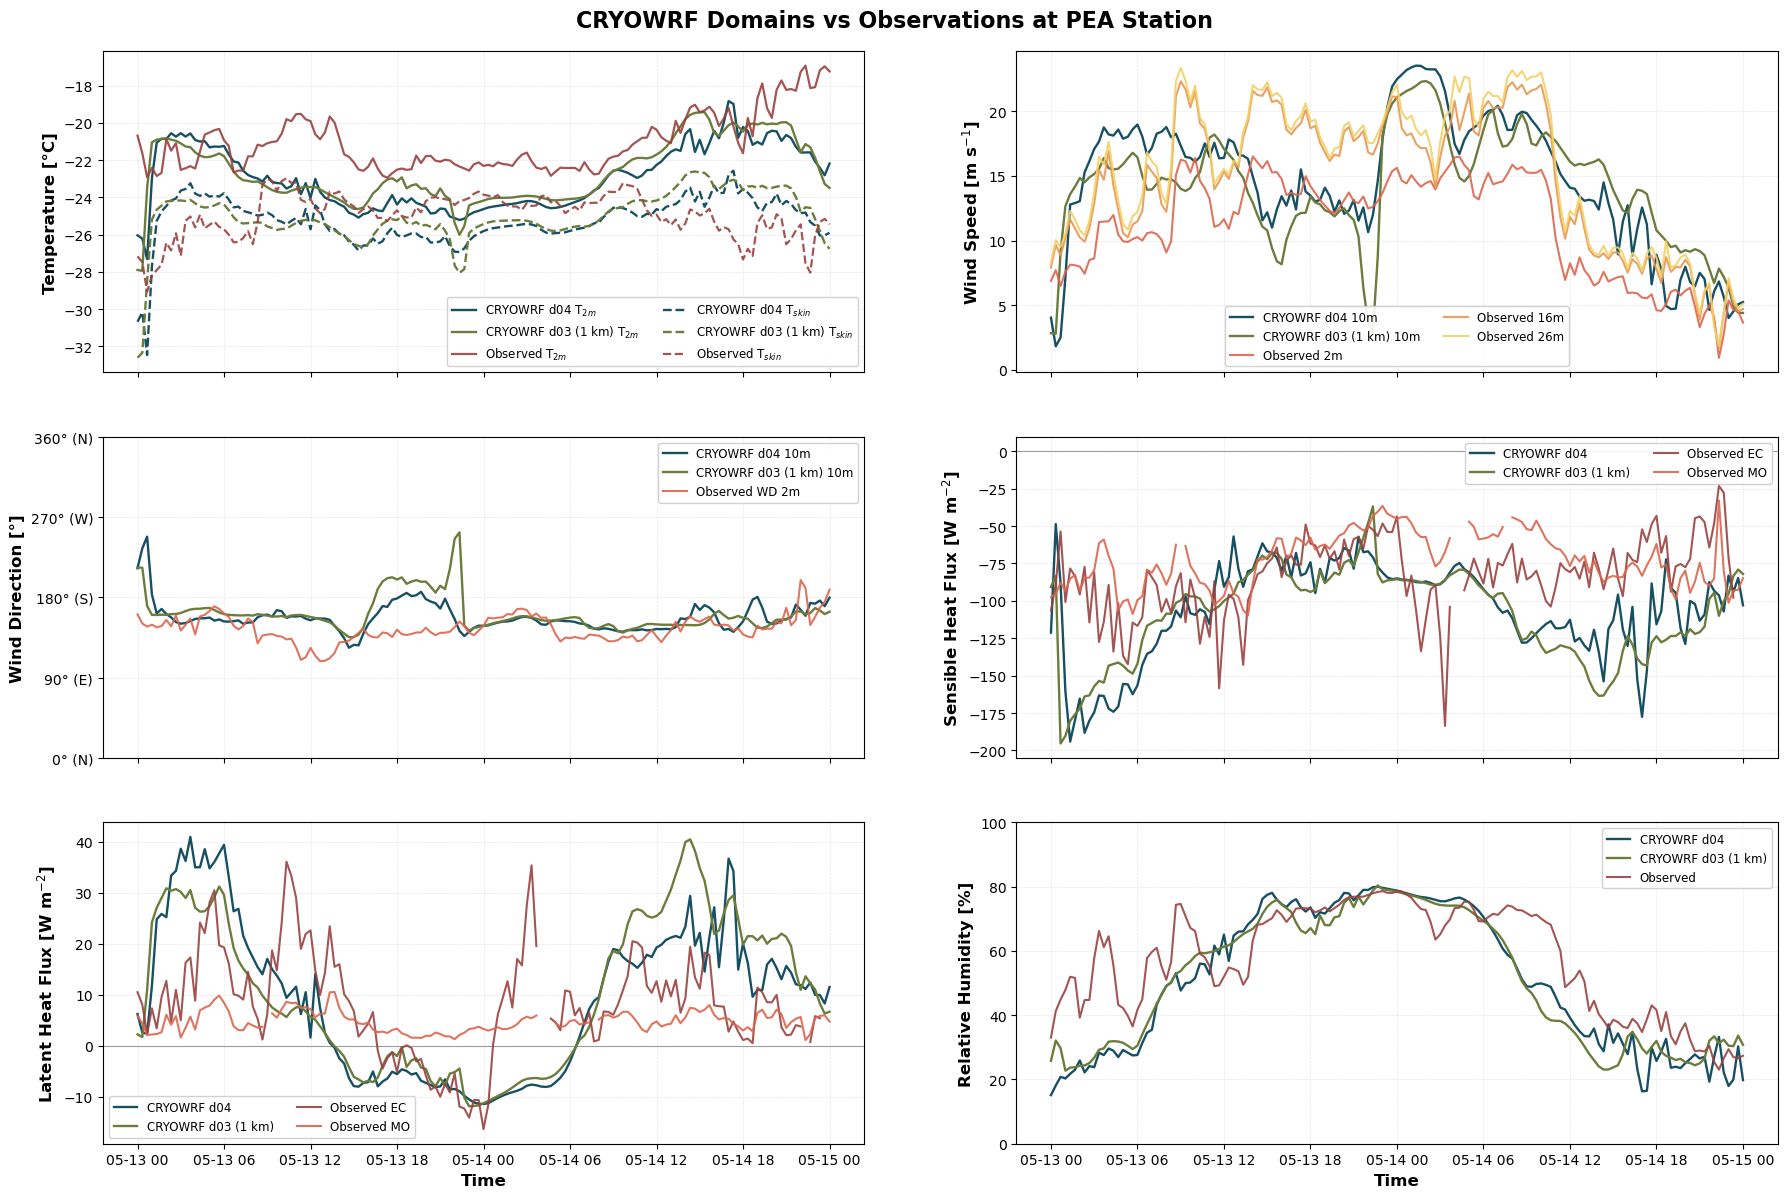

In [27]:
import cmcrameri.cm as cmc

# Use common timerange between d04 and d03 model outputs
start = max(df_interp.Time.iloc[0], df_interp_d03.Time.iloc[0])
end = min(df_interp.Time.iloc[-1], df_interp_d03.Time.iloc[-1])

avg_interval = '20min'
avg_interpolate = '15min'

# Resample model data to same interval as comparison
df_interp_mean = df_interp.resample(avg_interval).mean().loc[start:end]
df_interp_d03_mean = df_interp_d03.resample(avg_interval).mean().loc[start:end]

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('CRYOWRF Domains vs Observations at PEA Station', fontsize=16, fontweight='bold', y=0.995)

# Color design:
# - Models (d04/d03) use cool colors from same family
# - Observations use warm/contrasting colors
model_colors = cmc.batlow(np.linspace(0.18, 0.45, 2))
obs_colors = cmc.lajolla(np.linspace(0.35, 0.85, 4))

color_d04 = model_colors[0]
color_d03 = model_colors[1]
color_obs1 = obs_colors[0]
color_obs2 = obs_colors[1]
color_obs3 = obs_colors[2]
color_obs4 = obs_colors[3]

# Temperature (T2m and Tskin)
ax = axes[0, 0]
ax.plot(df_interp_mean['t2'] - 273.15, label='CRYOWRF d04 T$_{2m}$', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['t2'] - 273.15, label='CRYOWRF d03 (1 km) T$_{2m}$', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['TA'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed T$_{2m}$', linewidth=1.6, color=color_obs1, alpha=0.9
)

ax.plot(df_interp_mean['tskin'] - 273.15, label='CRYOWRF d04 T$_{skin}$', linewidth=1.7, linestyle='--', color=color_d04)
ax.plot(df_interp_d03_mean['tskin'] - 273.15, label='CRYOWRF d03 (1 km) T$_{skin}$', linewidth=1.7, linestyle='--', color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['SFTempK'][start:end], avg_interval, True, avg_interpolate, 80) - 273.15,
    label='Observed T$_{skin}$', linewidth=1.6, linestyle='--', color=color_obs1, alpha=0.9
)
ax.set_ylabel('Temperature [°C]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Wind Speed
ax = axes[0, 1]
ax.plot(df_interp_mean['speed10'], label='CRYOWRF d04 10m', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['speed10'], label='CRYOWRF d03 (1 km) 10m', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['WS2_Avg'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 2m', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.plot(
    resample_with_threshold(fluxes_16m['wind_speed'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 16m', linewidth=1.5, color=color_obs3, alpha=0.9
)
ax.plot(
    resample_with_threshold(fluxes_26m['wind_speed'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 26m', linewidth=1.5, color=color_obs4, alpha=0.9
)
ax.set_ylabel('Wind Speed [m s$^{-1}$]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Wind Direction
ax = axes[1, 0]
ax.plot(df_interp_mean['wind_dir'], label='CRYOWRF d04 10m', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['wind_dir'], label='CRYOWRF d03 (1 km) 10m', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['WD2'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed WD 2m', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.set_ylabel('Wind Direction [°]', fontsize=12, fontweight='bold')
ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_yticklabels(['0° (N)', '90° (E)', '180° (S)', '270° (W)', '360° (N)'])
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Sensible Heat Flux
ax = axes[1, 1]
ax.plot(df_interp_mean['hfx'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['hfx'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(fluxes_SFC['H'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed EC', linewidth=1.5, color=color_obs1, alpha=0.9
)
ax.plot(
    resample_with_threshold(MO_data['H'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed MO', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4, zorder=1)
ax.set_ylabel('Sensible Heat Flux [W m$^{-2}$]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Latent Heat Flux
ax = axes[2, 0]
ax.plot(df_interp_mean['lh'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['lh'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(fluxes_SFC['LE'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed EC', linewidth=1.5, color=color_obs1, alpha=0.9
)
ax.plot(
    resample_with_threshold(MO_data['LE'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed MO', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4, zorder=1)
ax.set_ylabel('Latent Heat Flux [W m$^{-2}$]', fontsize=12, fontweight='bold')
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Relative Humidity
ax = axes[2, 1]
has_rh = False
if 'rh' in df_interp_mean.columns:
    ax.plot(df_interp_mean['rh'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
    has_rh = True
if 'rh' in df_interp_d03_mean.columns:
    ax.plot(df_interp_d03_mean['rh'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
    has_rh = True
if 'RH' in data_obs.columns:
    ax.plot(
        resample_with_threshold(data_obs['RH'][start:end], avg_interval, True, avg_interpolate, 80),
        label='Observed', linewidth=1.5, color=color_obs1, alpha=0.9
    )
    has_rh = True

if has_rh:
    ax.set_ylabel('Relative Humidity [%]', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
else:
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.2, wspace=0.2)
plt.show()

In [37]:
# 6-panel domain maps per timestamp (d04)
# 1) 10 m wind speed + direction arrows
# 2) surface_snow_mix_ratio (g/kg, log)
# 3) sn_qs second layer (g/kg, log)
# 4) bs_qi lowest layer (g/kg, log)
# 5) bs_sublim_3d lowest layer (g/kg/s, log)
# 6) sn_sublim_3d lowest layer (g/kg/s, log)
# Terrain contours and PEA marker are overlaid on all panels.

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import wrf


output_dir = Path('/capstor/scratch/cscs/rengbers/results_PE_figs/d04_maps')
output_dir.mkdir(parents=True, exist_ok=True)

quiver_step = 8
terrain_contour_step = 250.0
log_vmin = 1e-12
log_vmax = 1e0


def _to_np(a):
    arr = wrf.to_np(a)
    if np.ma.isMaskedArray(arr):
        arr = arr.filled(np.nan)
    return np.asarray(arr, dtype=np.float64)


def _isel_time(da, t):
    return da.isel(Time=t) if hasattr(da, 'dims') and 'Time' in da.dims else da


def _first_vertical_dim(da):
    horizontal_dims = {'south_north', 'west_east', 'y', 'x'}
    for dim_name in da.dims:
        if dim_name not in horizontal_dims:
            return dim_name
    return None


def _extract_2d_at_level(da_t, which='lowest'):
    if len(da_t.dims) <= 2:
        return _to_np(da_t)

    vdim = _first_vertical_dim(da_t)
    if vdim is None:
        return np.squeeze(_to_np(da_t))

    layer_count = da_t.sizes[vdim]
    if which == 'lowest':
        idx = 0
    elif which == 'highest':
        idx = -1
    elif which == 'top_minus_1':
        idx = -2 if layer_count >= 2 else -1
    elif which == 'second_lowest':
        idx = 1 if layer_count >= 2 else 0
    else:
        raise ValueError(f'Unknown layer selector: {which}')

    return _to_np(da_t.isel({vdim: idx}))


def _mask_nonpositive(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return np.where(np.isfinite(arr) & (arr > 0), arr, np.nan)


def _robust_limits(arr, pmin=2.0, pmax=98.0, fallback=(0.0, 1.0), nonnegative=False):
    vals = np.asarray(arr, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        vmin, vmax = fallback
    else:
        vmin = float(np.nanpercentile(vals, pmin))
        vmax = float(np.nanpercentile(vals, pmax))
        if vmin == vmax:
            vmin = float(np.nanmin(vals))
            vmax = float(np.nanmax(vals))
        if vmin == vmax:
            vmin -= 0.5
            vmax += 0.5
    if nonnegative:
        vmin = max(0.0, vmin)
        vmax = max(vmin + 1e-12, vmax)
    return vmin, vmax


def _add_background(ax, lons, lats, ter_2d, contour_levels):
    if contour_levels is not None and contour_levels.size > 1:
        ax.contour(lons, lats, ter_2d, levels=contour_levels, colors='k', linewidths=0.35, alpha=0.45)
    # coords_PEA is [lat, lon]
    ax.scatter(coords_PEA[1], coords_PEA[0], s=35, c='red', edgecolors='white', linewidths=0.7, zorder=10)


if hasattr(speed10, 'dims') and 'Time' in speed10.dims:
    n_times = speed10.sizes['Time']
else:
    n_times = 1

surface_snow_mix_ratio_loaded = globals().get('surface_snow_mix_ratio', globals().get('surface_snow_mix_ratio_d03', None))
sn_qs_loaded = globals().get('sn_qs', globals().get('sn_qs_d03', None))
bs_sublim_loaded = globals().get('bs_sublim_3d', globals().get('bs_sublim_3d_d03', None))
sn_sublim_loaded = globals().get('sn_sublim_3d', globals().get('sn_sublim_3d_d03', None))

# Build fixed limits across all timesteps first.
speed_stack = []
for t in range(n_times):
    speed_stack.append(_to_np(_isel_time(speed10, t)))

speed_all = np.concatenate([arr.ravel() for arr in speed_stack]) if speed_stack else np.array([0.0])
smin, _smax_auto = _robust_limits(speed_all, fallback=(0.0, 20.0), nonnegative=True)
smax = 12.0
if smin >= smax:
    smin = 0.0

saved_count = 0
for t in range(0, n_times, 2):
    ter_t = _isel_time(ter, t)
    lats_da, lons_da = wrf.latlon_coords(ter_t)
    lats = _to_np(lats_da)
    lons = _to_np(lons_da)
    ter_2d = _to_np(ter_t)

    speed10_2d = _to_np(_isel_time(speed10, t))
    u10_2d = _to_np(_isel_time(u10, t))
    v10_2d = _to_np(_isel_time(v10, t))

    if surface_snow_mix_ratio_loaded is not None:
        ssmr_t = _isel_time(surface_snow_mix_ratio_loaded, t)
        ssmr_2d = _mask_nonpositive(_extract_2d_at_level(ssmr_t, which='lowest') * 1000.0)
    else:
        ssmr_2d = np.full_like(ter_2d, np.nan, dtype=float)

    if sn_qs_loaded is not None:
        sn_qs_t = _isel_time(sn_qs_loaded, t)
        sn_qs_2d = _mask_nonpositive(_extract_2d_at_level(sn_qs_t, which='second_lowest') * 1000.0)
    else:
        try:
            sn_qs_da = wrf.getvar(wrflist[t], 'SN_QS', timeidx=0)
            sn_qs_2d = _mask_nonpositive(_extract_2d_at_level(sn_qs_da, which='second_lowest') * 1000.0)
        except Exception:
            sn_qs_2d = np.full_like(ter_2d, np.nan, dtype=float)

    bs_qi_t = _isel_time(bs_qi, t)
    bs_qi_2d = _mask_nonpositive(_extract_2d_at_level(bs_qi_t, which='lowest') * 1000.0)

    if bs_sublim_loaded is not None:
        bs_sub_t = _isel_time(bs_sublim_loaded, t)
        bs_sub_2d = _mask_nonpositive(np.abs(_extract_2d_at_level(bs_sub_t, which='lowest')) * 1000.0)
    else:
        bs_sub_2d = np.full_like(ter_2d, np.nan, dtype=float)

    if sn_sublim_loaded is not None:
        sn_sub_t = _isel_time(sn_sublim_loaded, t)
        sn_sub_2d = _mask_nonpositive(np.abs(_extract_2d_at_level(sn_sub_t, which='second_lowest')) * 1000.0)
    else:
        sn_sub_2d = np.full_like(ter_2d, np.nan, dtype=float)

    max_ter = np.nanmax(ter_2d)
    contour_levels = np.arange(0.0, max_ter + terrain_contour_step, terrain_contour_step) if np.isfinite(max_ter) and max_ter > 0 else None

    fig, axes = plt.subplots(2, 3, figsize=(24, 14), constrained_layout=True)
    axes = axes.ravel()

    # Panel 1: wind speed + arrows
    cf0 = axes[0].pcolormesh(lons, lats, speed10_2d, cmap='viridis', vmin=smin, vmax=smax, shading='auto')
    axes[0].quiver(
        lons[::quiver_step, ::quiver_step],
        lats[::quiver_step, ::quiver_step],
        u10_2d[::quiver_step, ::quiver_step],
        v10_2d[::quiver_step, ::quiver_step],
        color='white', width=0.0018, scale=220
    )
    _add_background(axes[0], lons, lats, ter_2d, contour_levels)
    axes[0].set_title('10 m Wind Speed + Direction')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    plt.colorbar(cf0, ax=axes[0], label='m/s')

    # Panel 2: surface snow mix ratio (g/kg), log scale
    cf1 = axes[1].pcolormesh(
        lons, lats, ssmr_2d,
        cmap='Blues',
        norm=LogNorm(vmin=log_vmin, vmax=log_vmax),
        shading='auto'
    )
    _add_background(axes[1], lons, lats, ter_2d, contour_levels)
    axes[1].set_title('Surface Snow Mix Ratio')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    plt.colorbar(cf1, ax=axes[1], label='g/kg', ticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0])

    # Panel 3: sn_qs second layer (g/kg), log scale
    cf2 = axes[2].pcolormesh(
        lons, lats, sn_qs_2d,
        cmap='Blues',
        norm=LogNorm(vmin=log_vmin, vmax=log_vmax),
        shading='auto'
    )
    _add_background(axes[2], lons, lats, ter_2d, contour_levels)
    axes[2].set_title('SN_QS Second Layer')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    plt.colorbar(cf2, ax=axes[2], label='g/kg', ticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0])

    # Panel 4: bs_qi lowest layer (g/kg), log scale
    cf3 = axes[3].pcolormesh(
        lons, lats, bs_qi_2d,
        cmap='Blues',
        norm=LogNorm(vmin=log_vmin, vmax=log_vmax),
        shading='auto'
    )
    _add_background(axes[3], lons, lats, ter_2d, contour_levels)
    axes[3].set_title('BS_QI Lowest Layer')
    axes[3].set_xlabel('Longitude')
    axes[3].set_ylabel('Latitude')
    plt.colorbar(cf3, ax=axes[3], label='g/kg', ticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0])

    # Panel 5: bs_sublim_3d lowest layer (g/kg/s), log scale, slightly different cmap
    cf4 = axes[4].pcolormesh(
        lons, lats, bs_sub_2d,
        cmap='Purples',
        norm=LogNorm(vmin=log_vmin, vmax=log_vmax),
        shading='auto'
    )
    _add_background(axes[4], lons, lats, ter_2d, contour_levels)
    axes[4].set_title('|BS_QI_SUBLIM3D| Lowest Layer')
    axes[4].set_xlabel('Longitude')
    axes[4].set_ylabel('Latitude')
    plt.colorbar(cf4, ax=axes[4], label='g/kg/s', ticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0])

    # Panel 6: sn_sublim_3d lowest layer (g/kg/s), log scale, slightly different cmap
    cf5 = axes[5].pcolormesh(
        lons, lats, sn_sub_2d,
        cmap='Greens',
        norm=LogNorm(vmin=log_vmin, vmax=log_vmax),
        shading='auto'
    )
    _add_background(axes[5], lons, lats, ter_2d, contour_levels)
    axes[5].set_title('|SN_QI_SUBLIM3D| Second Layer')
    axes[5].set_xlabel('Longitude')
    axes[5].set_ylabel('Latitude')
    plt.colorbar(cf5, ax=axes[5], label='g/kg/s', ticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0])

    if hasattr(speed10, 'dims') and 'Time' in speed10.dims:
        timestamp = str(speed10.Time.values[t])
    else:
        timestamp = f't{t:03d}'

    fig.suptitle(f'd04 Maps at {timestamp}')
    safe_time = timestamp.replace(':', '-').replace(' ', '_')
    out_file = output_dir / f'd04_maps_spinup_{t:03d}_{safe_time}.png'
    plt.savefig(out_file, dpi=200)
    plt.close(fig)
    saved_count += 1

print(f'Done. Saved {saved_count} map figures to {output_dir}')
print(f'Wind speed colorbar range: {smin:.4g} to {smax:.4g} m/s')
print('Mixing-ratio shared log scale: 1e-12 to 1e0 g/kg')
print('Sublimation shared log scale: 1e-12 to 1e0 g/kg/s')

/tmp/ipykernel_233435/205296244.py:171: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cf0 = axes[0].pcolormesh(lons, lats, speed10_2d, cmap='viridis', vmin=smin, vmax=smax, shading='auto')
/tmp/ipykernel_233435/205296244.py:186: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cf1 = axes[1].pcolormesh(
/tmp/ipykernel_233435/205296244.py:199: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormes

Done. Saved 84 map figures to /capstor/scratch/cscs/rengbers/results_PE_figs/d04_maps
Wind speed colorbar range: 0.1129 to 12 m/s
Mixing-ratio shared log scale: 1e-12 to 1e0 g/kg
Sublimation shared log scale: 1e-12 to 1e0 g/kg/s


In [30]:
sn_sublim_3d

<xarray.DataArray 'SN_QI_SUBLIM3D' (Time: 168, snowpack_surface_layer: 8,
                                    south_north: 200, west_east: 200)> Size: 215MB
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]], dtype=float32)
Coordinates:
    XLONG     (south_north, west_east) float32 160kB 22.8 22.8 ... 23.94 23.94
    XLAT      (south_north, west_east) float32 160kB -72.14 -72.14 ... -71.78
    XTIME     (Time) float64 1kB 0.0 5.0 10.0 15.0 ... 820.0 825.0 830.0 835.0
  * Time      (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
    datetime  (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
Dimensions without coordinates: snowpack_surface_layer, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  sfc layer bs snow sublim
    units:        kg kg-1 s-1
    stagger:      
    coordinates:  XLONG XLAT XTIME
    projection:   PolarStereographic(stand_lon=23.34695053100586, moad_cen_la...

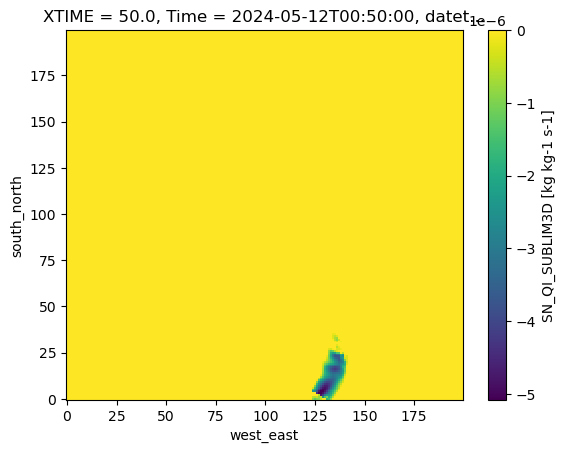

In [36]:
sn_sublim_3d.isel(Time=10).isel(snowpack_surface_layer=0).plot()

In [ ]:
sn

In [16]:
sn_qs

<xarray.DataArray 'SN_QS' (Time: 168, snowpack_surface_layer: 8,
                           south_north: 200, west_east: 200)> Size: 215MB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          1.26438682e-12, 8.32623068e-11, 1.08244468e-12],
         [1.90458371e-10, 8.24945875e-11, 1.51532911e-10, ...,
          1.61431563e-10, 1.08456430e-12, 1.00548649e-12],
         [9.13133527e-11, 1.67320754e-10, 6.54571050e-11, ...,
          8.15855578e-11, 8.06360603e-11, 1.08444384e-12]],

        [[1.74083848e-12, 1.41438846e-12, 2.41833051e-12, ...,
          1.01630314e-12, 1.02704412e-12, 1.04049657e-12],
         [9.39643433e-11, 1.09157830e-11, 9.66535810e-11, ...,
          9.55184057e-11, 1.12171481e-12, 1.03866633e-12],
         [1.15570283e-10, 1.97478506e-10, 1.29752736e-10, ...,
          1.01371396e-12, 9.52665793e-11, 1.03556703e-12],
         ...,
         [1.62409225e-10, 2.08201678e-10, 9.70976285e-11, ...,
          1.65295388e-10, 8.32513503e-11, 8.31914052e-11],
         [7.81388912e-11, 9.91884075e-11, 2.18480276e-10, ...,
          8.20359197e-11, 1.12158817e-12, 1.11643355e-12],
         [1.63416003e-10, 2.03632944e-11, 1.27187136e-10, ...,
          1.19861814e-12, 1.19738486e-12, 1.11179067e-12]]]],
      dtype=float32)
Coordinates:
    XLONG     (south_north, west_east) float32 160kB 22.8 22.8 ... 23.94 23.94
    XLAT      (south_north, west_east) float32 160kB -72.14 -72.14 ... -71.78
    XTIME     (Time) float64 1kB 0.0 5.0 10.0 15.0 ... 820.0 825.0 830.0 835.0
  * Time      (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
    datetime  (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
Dimensions without coordinates: snowpack_surface_layer, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  sn surface_qs
    units:        kg kg-1
    stagger:      
    coordinates:  XLONG XLAT XTIME
    projection:   PolarStereographic(stand_lon=23.34695053100586, moad_cen_la...

In [14]:
sn_qs

<xarray.DataArray 'SN_QS' (Time: 168, snowpack_surface_layer: 8,
                           south_north: 200, west_east: 200)> Size: 215MB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          1.26438682e-12, 8.32623068e-11, 1.08244468e-12],
         [1.90458371e-10, 8.24945875e-11, 1.51532911e-10, ...,
          1.61431563e-10, 1.08456430e-12, 1.00548649e-12],
         [9.13133527e-11, 1.67320754e-10, 6.54571050e-11, ...,
          8.15855578e-11, 8.06360603e-11, 1.08444384e-12]],

        [[1.74083848e-12, 1.41438846e-12, 2.41833051e-12, ...,
          1.01630314e-12, 1.02704412e-12, 1.04049657e-12],
         [9.39643433e-11, 1.09157830e-11, 9.66535810e-11, ...,
          9.55184057e-11, 1.12171481e-12, 1.03866633e-12],
         [1.15570283e-10, 1.97478506e-10, 1.29752736e-10, ...,
          1.01371396e-12, 9.52665793e-11, 1.03556703e-12],
         ...,
         [1.62409225e-10, 2.08201678e-10, 9.70976285e-11, ...,
          1.65295388e-10, 8.32513503e-11, 8.31914052e-11],
         [7.81388912e-11, 9.91884075e-11, 2.18480276e-10, ...,
          8.20359197e-11, 1.12158817e-12, 1.11643355e-12],
         [1.63416003e-10, 2.03632944e-11, 1.27187136e-10, ...,
          1.19861814e-12, 1.19738486e-12, 1.11179067e-12]]]],
      dtype=float32)
Coordinates:
    XLONG     (south_north, west_east) float32 160kB 22.8 22.8 ... 23.94 23.94
    XLAT      (south_north, west_east) float32 160kB -72.14 -72.14 ... -71.78
    XTIME     (Time) float64 1kB 0.0 5.0 10.0 15.0 ... 820.0 825.0 830.0 835.0
  * Time      (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
    datetime  (Time) datetime64[ns] 1kB 2024-05-12 ... 2024-05-12T13:55:00
Dimensions without coordinates: snowpack_surface_layer, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  sn surface_qs
    units:        kg kg-1
    stagger:      
    coordinates:  XLONG XLAT XTIME
    projection:   PolarStereographic(stand_lon=23.34695053100586, moad_cen_la...

In [27]:
bs_sublim_3d

NameError: name 'bs_sublim_3d' is not defined